# Khisto — optimal binning histograms

A good histogram should reveal the structure of your data without asking you to
guess the right number of bins first. Khisto chooses the bins for you: it uses
the **Khiops optimal binning algorithm** (the MODL / Minimum Description Length
principle) to pick both the number of bins *and* their — possibly unequal —
widths, so dense regions get fine bins and sparse regions get wide ones.

This notebook goes **from the simplest case to a richer one**:

1. **Quick start** — two textbook distributions (a Gaussian and a heavy-tailed
   Pareto), each in a single call.
2. **A three-component mixture** — a more realistic example used to tour the
   full API.

Throughout, we plot the **density** rather than raw counts. With variable-width
bins this is almost always the right choice: a tall-but-narrow bin and a
short-but-wide bin can hold the *same* number of points, so only the density
(count divided by bin width) shows the true shape of the distribution.

> 📚 For a didactic walk-through of optimal histograms — from the simplest to the
> most complex — see the
> [Khiops histograms guide](https://github.com/KhiopsML/khiops-doc/blob/dev/docs/learn/histograms.md).


## 1. Quick start

The simplest promise: one call, sensible bins, a readable density. We start with
two distributions where the "right" binning is well understood, so you can see
that Khisto does the natural thing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from khisto import histogram
from khisto.matplotlib import hist

SEED = 42

### A standard Gaussian — linear scale

For a bell curve, a linear axis is the natural view. `khisto.matplotlib.hist`
works like `plt.hist`, but the bins adapt to the data.

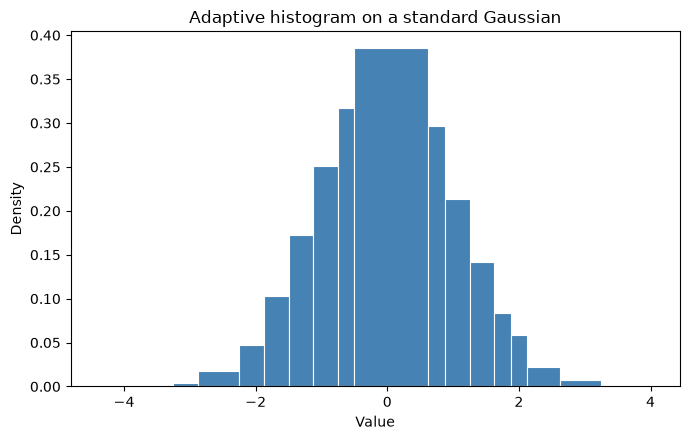

In [ ]:
gaussian = np.random.default_rng(SEED).normal(0, 1, 10000)

fig, ax = plt.subplots(figsize=(7, 4.5))
hist(gaussian, ax=ax, color="steelblue", edgecolor="white", linewidth=0.8)
ax.set_title("Adaptive histogram on a standard Gaussian")
ax.set_xlabel("Value")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

### A heavy-tailed Pareto — log-log scale

Heavy-tailed data spans several orders of magnitude, so a **log-log** view is
the natural one. Fixed-width bins struggle here — they are either too coarse in
the body or empty in the tail — while adaptive bins stay informative all the way
out.

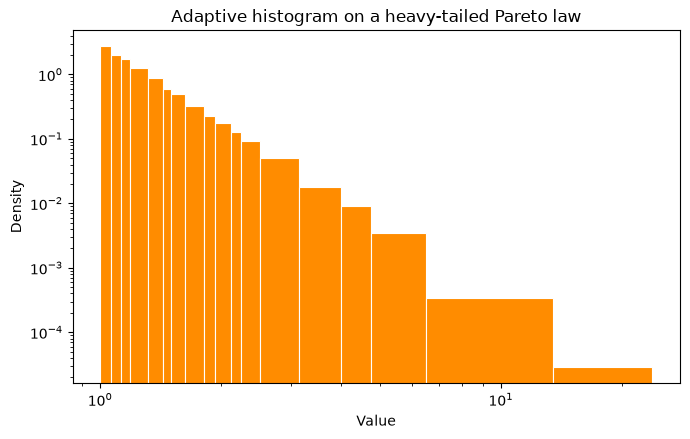

In [ ]:
pareto = np.random.default_rng(SEED).pareto(3, 10000) + 1.0  # shift to start at 1 for log axes

fig, ax = plt.subplots(figsize=(7, 4.5))
hist(pareto, ax=ax, color="darkorange", edgecolor="white", linewidth=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Adaptive histogram on a heavy-tailed Pareto law")
ax.set_xlabel("Value")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

## 2. A richer example — a three-component mixture

To exercise the rest of the API we use a more realistic distribution that mixes
three components:

- a **standard Gaussian** (broad central mass),
- a **narrow, peaked Gaussian** (a sharp mode), and
- a **lognormal** (a stretched right tail).

10,000 samples keep the adaptive refinement visible while staying fast to
compute. This single `data` array is reused for every example below.

In [4]:
rng = np.random.default_rng(SEED)
data = np.concatenate([
    rng.normal(0, 1, 5000),       # standard Gaussian
    rng.normal(3, 0.25, 2000),    # narrow, peaked Gaussian
    rng.lognormal(mean=0, sigma=1, size=3000),  # lognormal right tail
])

print(f"Samples: {data.shape[0]}")
print(f"Range: [{data.min():.2f}, {data.max():.2f}]")
print("Shape: a broad bell, a sharp spike near 3, and a long lognormal tail.")

Samples: 10000
Range: [-3.65, 56.03]
Shape: a broad bell, a sharp spike near 3, and a long lognormal tail.


### Adaptive vs fixed-width bins — linear scale

The same data, the same density normalization, the same axes — only the binning
differs. Fixed-width bins blur the sharp mode and waste resolution on the empty
tail; Khisto's adaptive bins keep both readable.

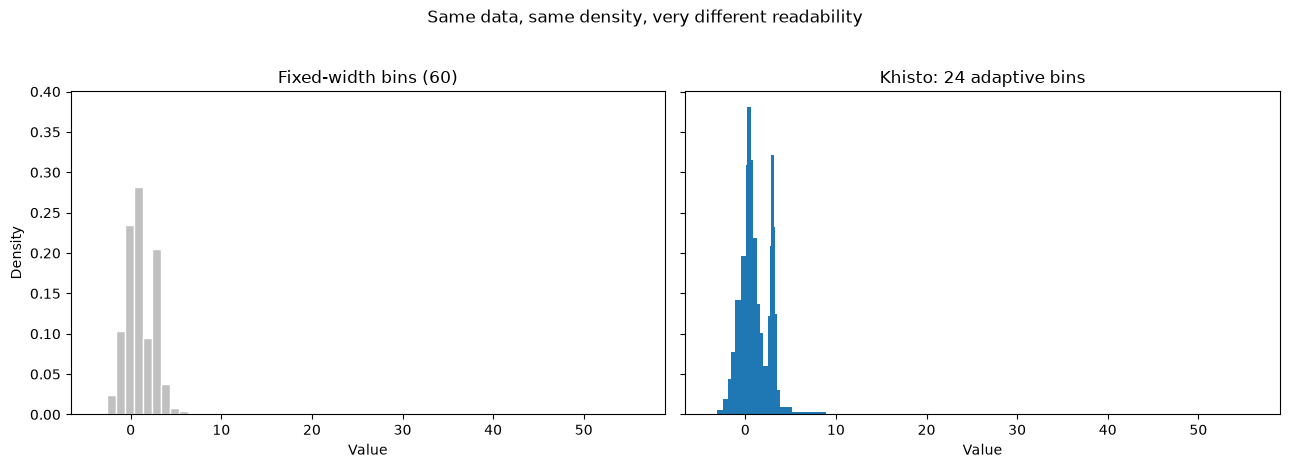

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

# Matplotlib / NumPy: fixed-width bins (density)
axes[0].hist(data, bins=60, density=True, color="silver", edgecolor="white")
axes[0].set_title("Fixed-width bins (60)")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")

# Khisto: adaptive bins (density)
hist(data, ax=axes[1], color="steelblue", edgecolor="white", linewidth=0.8)
axes[1].set_title(f"Khisto: {len(hist(data, density=True)[0])} adaptive bins")
axes[1].set_xlabel("Value") 

fig.suptitle("Same data, same density, very different readability", y=1.03)
plt.tight_layout()
plt.show()

### The same comparison — log-log scale

On log-log axes the tail behaviour comes to the foreground. Empty fixed-width
bins simply vanish (a zero has no place on a log axis), whereas adaptive bins
widen to keep the tail populated and visible.

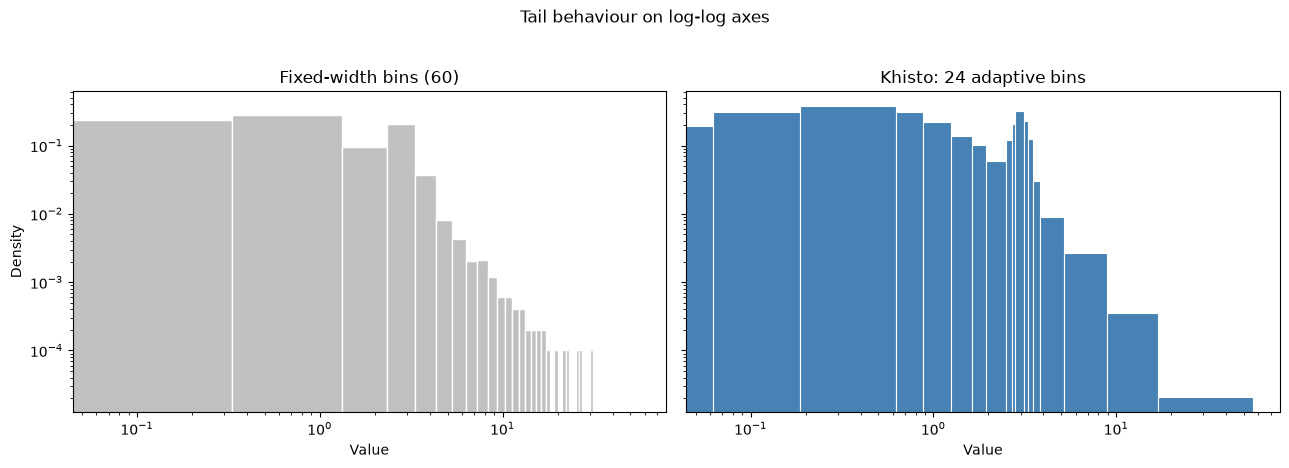

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)

axes[0].hist(data, bins=60, density=True, color="silver", edgecolor="white")
axes[0].set_title("Fixed-width bins (60)")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")
axes[0].set_xscale("log")
axes[0].set_yscale("log")

hist(data, ax=axes[1], color="steelblue", edgecolor="white", linewidth=0.8)
axes[1].set_title(f"Khisto: {len(kh_dens)} adaptive bins")
axes[1].set_xlabel("Value")
axes[1].set_xscale("log")
axes[1].set_yscale("log")

fig.suptitle("Tail behaviour on log-log axes", y=1.03)
plt.tight_layout()
plt.show()

## 3. NumPy-like API: `khisto.histogram`

`khisto.histogram` is a drop-in replacement for `numpy.histogram`: same return
value `(hist, bin_edges)`, but the bins adapt to the data instead of being
fixed-width.

In [7]:
hist_counts, bin_edges = histogram(data)

print(f"Number of bins: {len(hist_counts)}")
print(f"Bin edges: {bin_edges}")
print(f"Frequencies: {hist_counts}")

Number of bins: 24
Bin edges: [-3.6484375 -3.125     -2.4375    -1.9375    -1.625     -1.125
 -0.5        0.0625     0.1875     0.625      0.875      1.25
  1.625      1.9375     2.5        2.6875     2.8125     3.125
  3.3125     3.5        3.8125     5.1875     8.9375    16.875
 56.03125  ]
Frequencies: [   2.   36.   99.  137.  386.  890. 1101.  386. 1668.  788.  818.  515.
  316.  340.  228.  261. 1006.  435.  234.   94.  124.  100.   28.    8.]


In [8]:
# With density normalization the integral over the range is ~1
density, bin_edges = histogram(data, density=True)

widths = np.diff(bin_edges)
integral = np.sum(density * widths)
print(f"Integral of density: {integral:.6f}")

Integral of density: 1.000000


In [9]:
# Cap the number of bins
hist_limited, edges_limited = histogram(data, max_bins=5)
print(f"Limited to max 5 bins: got {len(hist_limited)} bins")
print(f"Bin edges: {edges_limited}")

Limited to max 5 bins: got 5 bins
Bin edges: [-3.6484375  0.         4.         8.        16.        56.03125  ]


## 4. Matplotlib API: `khisto.matplotlib.hist`

`khisto.matplotlib.hist` keeps the familiar matplotlib workflow. With
variable-width bins, **density** is the view to reach for first.

### Cumulative plots

`khisto.matplotlib.hist` follows matplotlib's `cumulative` semantics, including
the cumulative density (CDF), raw cumulative counts, and reverse accumulation.

Text(0, 0.5, 'Cumulative probability')

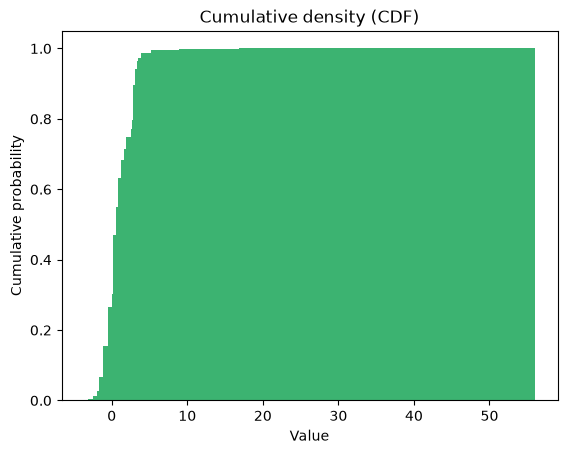

In [27]:
# Cumulative density (CDF) first — the most interpretable cumulative view
cdf_n, cdf_bins, _ = hist(data, density=True, cumulative=True,
                          color="mediumseagreen")
plt.title("Cumulative density (CDF)")
plt.xlabel("Value")
plt.ylabel("Cumulative probability")

## 5. Core API: `compute_histograms` and `HistogramResult`

When a single histogram is not enough, the core API exposes the full sequence of
granularities and tells you exactly where Khiops chooses to stop.

In [16]:
from khisto.core import compute_histograms

results = compute_histograms(data)

print(f"Number of granularity levels: {len(results)}\n")
print("Granularity levels:")
for result in results:
    marker = " <- BEST" if result.is_best else ""
    print(f"  Granularity {result.granularity}: {len(result.frequencies)} bins{marker}")

Number of granularity levels: 12

Granularity levels:
  Granularity 0: 1 bins
  Granularity 1: 2 bins
  Granularity 2: 3 bins
  Granularity 3: 3 bins
  Granularity 4: 4 bins
  Granularity 5: 5 bins
  Granularity 6: 8 bins
  Granularity 7: 11 bins
  Granularity 8: 18 bins
  Granularity 9: 25 bins
  Granularity 10: 26 bins
  Granularity 11: 24 bins <- BEST


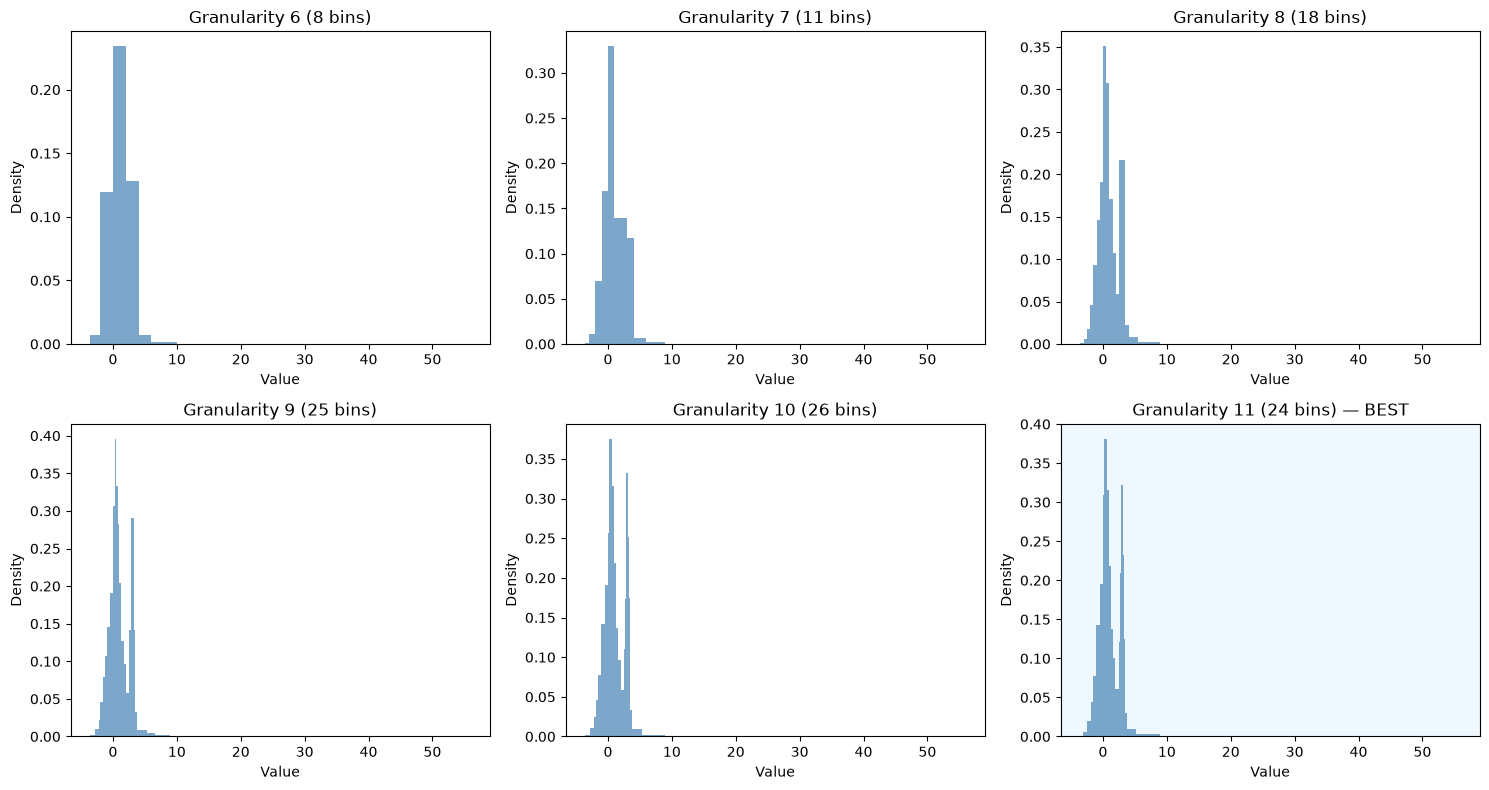

In [32]:
# Each level carries densities, so we visualize the series as densities
n_levels = min(6, len(results))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, result in enumerate(results[n_levels:]):
    ax = axes[i]
    ax.stairs(result.densities, result.bin_edges, fill=True, alpha=0.7,
              color="steelblue")
    title = f"Granularity {result.granularity} ({len(result.frequencies)} bins)"
    if result.is_best:
        title += " — BEST"
        ax.set_facecolor("aliceblue")
    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")

# Hide any unused axes
for ax in axes[n_levels:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Summary

Khisto gives you a better histogram without making you tune bins by hand:

1. **`khisto.histogram`** — a NumPy-like API with adaptive bins.
2. **`khisto.matplotlib.hist`** — readable plots with the usual matplotlib
   workflow; reach for `density=True` first.
3. **`khisto.core.compute_histograms`** — full control over the granularity
   series, with `HistogramResult` exposing counts, probabilities and densities.

To go further, the
[Khiops histograms guide](https://github.com/KhiopsML/khiops-doc/blob/dev/docs/learn/histograms.md)
builds the intuition from the simplest histogram to the most complex.